In [7]:

import sklearn, xgboost, shap, joblib
print("sklearn :", sklearn.__version__)
print("xgboost :", xgboost.__version__)
print("joblib  :", joblib.__version__)

sklearn : 1.9.0
xgboost : 3.3.0
joblib  : 1.5.3


In [8]:
# %pip install seaborn

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [10]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)
from xgboost import XGBClassifier

In [11]:
"""
## 3. Load Dataset
 
Loads the validated 30 000-row student dataset produced in Week 1.
No rows should be dropped here — the audit notebook confirmed zero nulls
and zero duplicates.
"""
 
DATA_PATH = r"C:\Users\aishw\SAR-Student-Success-Retention\datasets\student_success_dataset_30000.csv"
 
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (30000, 70)


,student_id,department,specialization,current_year,semester,gender,cgpa,semester_gpa,cgpa_trend,backlog_count,...,stress_score,time_management_score,consistency_score,academic_risk_band,dropout_risk_band,placement_risk_band,recommended_intervention,recommended_career_path,recommended_certification,recommended_course_track
0,STU202600001,Computer Engineering,Full Stack Development,Third Year,6,Male,9.00,9.15,Stable,1,...,62.52,61.18,75.33,Low,Low,Medium,Routine Academic Mentoring & Growth Tracking,IT Systems Consultant,Project Management Professional (PMP) Baseline,Academic Support & Catch-Up Track
1,STU202600002,Civil Engineering,Environmental Engineering,Second Year,3,Female,8.25,8.31,Stable,0,...,34.62,59.95,63.80,Low,Low,High,Routine Academic Mentoring & Growth Tracking,Structural & Infrastructure Planner,Project Management Professional (PMP) Baseline,Entrepreneurship Track
2,STU202600003,AI & ML,Computer Vision,Final Year,7,Female,8.81,8.79,Stable,0,...,34.43,74.90,91.29,Low,Low,Low,Routine Academic Mentoring & Growth Tracking,AI/ML Research Specialist,AWS Certified Machine Learning Specialty,Placement Fast Track
3,STU202600004,Electronics & Telecommunication,Embedded Systems,First Year,2,Male,8.83,8.69,Stable,0,...,32.98,72.21,88.28,Low,Low,High,Routine Academic Mentoring & Growth Tracking,Embedded Systems & IoT Engineer,PTC IoT Developer Certification,Academic Support & Catch-Up Track
4,STU202600005,Mechanical Engineering,CAD/CAM,Third Year,6,Male,9.34,9.36,Stable,0,...,45.71,74.01,87.37,Low,Low,Low,Routine Academic Mentoring & Growth Tracking,Product Design Engineer,Project Management Professional (PMP) Baseline,Placement Fast Track


In [12]:
"""
## 4. Feature / Target Split
 
Columns removed from X:
- `student_id`                  — identifier, not a feature
- `academic_risk_score`         — direct numerical source of the label → leakage
- `academic_risk_band`          — the target itself
- `dropout_risk_band`           — separate target, not used here
- `placement_risk_band`         — separate target, not used here
- `placement_probability`       — derived score for a different target
- `placement_readiness_score`   — derived score for a different target
- `career_readiness_score`      — derived score for a different target
 
Any additional columns that were confirmed as leakage during the dataset audit
should be added to DROP_COLS before training.
"""
 
TARGET = "academic_risk_band"
 
# In model_v1_baseline.ipynb:
DROP_COLS = [
    "student_id", "academic_risk_score", "academic_risk_band",
    "dropout_risk_band", "placement_risk_band", "placement_probability",
    "placement_readiness_score", "career_readiness_score",
    "recommended_intervention", "recommended_career_path",
    "recommended_certification", "recommended_course_track"
]

 
# Only drop columns that actually exist (safe for future schema changes)
DROP_COLS = [c for c in DROP_COLS if c in df.columns]
 
X = df.drop(columns=DROP_COLS)
y = df[TARGET]
 
print("Features shape :", X.shape)
print("Target shape   :", y.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nPercentages:")
print((y.value_counts(normalize=True) * 100).round(2))
 

Features shape : (30000, 58)
Target shape   : (30000,)

Target distribution:
academic_risk_band
Low         24390
Medium       3754
High         1691
Critical      165
Name: count, dtype: int64

Percentages:
academic_risk_band
Low         81.30
Medium      12.51
High         5.64
Critical     0.55
Name: proportion, dtype: float64


In [13]:
"""
## 5. Target Encoding
 
XGBClassifier requires integer class labels.
LabelEncoder is saved alongside the model so predictions can be decoded later.
 
Encoding order will be:
  Critical → 0  |  High → 1  |  Low → 2  |  Medium → 3  (alphabetical default)
"""
 
le = LabelEncoder()
y_enc = le.fit_transform(y)
 
print("Classes:", le.classes_)
print("Encoded values:", np.unique(y_enc))
 
# Save encoder immediately — used by Person B, C, D
joblib.dump(le, "label_encoder_academic_risk.pkl")
print("\nlabel_encoder_academic_risk.pkl saved.")

Classes: ['Critical' 'High' 'Low' 'Medium']
Encoded values: [0 1 2 3]

label_encoder_academic_risk.pkl saved.


In [14]:
"""
## 6. Stratified Train/Test Split
 
80 / 20 split, stratified on the encoded target to preserve the class
imbalance ratio in both sets.
"""
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc,
)
 
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
 
# Verify stratification held
for split_name, split_y in [("Train", y_train), ("Test", y_test)]:
    vals, counts = np.unique(split_y, return_counts=True)
    pcts = (counts / counts.sum() * 100).round(2)
    decoded = le.inverse_transform(vals)
    print(f"\n{split_name} distribution:")
    for d, p in zip(decoded, pcts):
        print(f"  {d:8s} {p}%")

X_train: (24000, 58)
X_test : (6000, 58)

Train distribution:
  Critical 0.55%
  High     5.64%
  Low      81.3%
  Medium   12.51%

Test distribution:
  Critical 0.55%
  High     5.63%
  Low      81.3%
  Medium   12.52%


In [15]:
numeric_cols     = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
 
print(f"Numeric columns     : {len(numeric_cols)}")
print(f"Categorical columns : {len(categorical_cols)}")
 
 

Numeric columns     : 51
Categorical columns : 7


In [16]:
"""
## 8. Class Imbalance Handling
 
The dataset is heavily skewed (Low ≈ 81 %).
XGBoost has a built-in `scale_pos_weight` parameter, but for multi-class
imbalance the recommended approach is `sample_weight` passed to `fit()`.
 
We compute per-sample weights using sklearn's `compute_sample_weight` with
strategy="balanced", which gives higher weight to minority classes.
"""
 
from sklearn.utils.class_weight import compute_sample_weight
 
sample_weights_train = compute_sample_weight(class_weight="balanced", y=y_train)
 
# Inspect effective class weights
class_weights = compute_sample_weight(class_weight="balanced", y=y_train)
unique_classes, inverse = np.unique(y_train, return_inverse=True)
mean_weight_per_class = [
    class_weights[y_train == c].mean() for c in unique_classes
]
print("Effective mean weight per class:")
for cls, w in zip(le.inverse_transform(unique_classes), mean_weight_per_class):
    print(f"  {cls:8s}  weight = {w:.4f}")

Effective mean weight per class:
  Critical  weight = 45.4545
  High      weight = 4.4346
  Low       weight = 0.3075
  Medium    weight = 1.9980


In [17]:
"""
## 9. Preprocessing Pipeline
 
XGBoost handles numeric features natively (including sparse / ordinal data),
so we only need:
- Median imputation for numerics   (zero missing values confirmed, but defensive)
- Most-frequent imputation + Ordinal encoding for categoricals
 
OrdinalEncoder is used instead of OneHotEncoder to keep feature count low and
maintain XGBoost's ability to split on ordinal boundaries.
`handle_unknown="use_encoded_value"` with `unknown_value=-1` ensures
unseen categories at inference time don't crash the pipeline.
"""
 
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1,
                    ),
                ),
            ]),
            categorical_cols,
        ),
    ],
    remainder="drop",
)
 
print("Preprocessor created.")
 

Preprocessor created.


In [18]:
"""
## 10. XGBoost Classifier
 
Key choices:
- `objective="multi:softprob"` — returns calibrated probabilities per class
- `eval_metric="mlogloss"`     — appropriate for multi-class
- `use_label_encoder=False`    — deprecated; we encode labels ourselves (Cell 5)
- `n_estimators=500`           — generous; early stopping will trim this
- `max_depth=6`                — standard starting point, avoids deep memorisation
- `learning_rate=0.05`         — lower LR + more trees → better generalisation
- `subsample=0.8`              — row sub-sampling for variance reduction
- `colsample_bytree=0.8`       — feature sub-sampling per tree
- `min_child_weight=5`         — prevents splits on tiny leaf groups (Critical class)
- `gamma=1`                    — minimum loss reduction required to make a split
- `reg_alpha=0.1`              — L1 regularisation
- `reg_lambda=1`               — L2 regularisation (XGBoost default)
- `random_state=42`            — reproducibility
- `n_jobs=-1`                  — use all available CPU cores
"""
 
xgb_clf = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    num_class=len(le.classes_),
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
 
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier",   xgb_clf),
    ]
)
 
print("XGBoost pipeline created.")
 

XGBoost pipeline created.


In [19]:
"""
## 11. Training
 
Early stopping (patience = 30 rounds) on a 10 % validation hold-out carved
from the training set.  This prevents over-fitting and automatically selects
the optimal number of trees.
 
`sample_weight` is passed via `classifier__sample_weight` in Pipeline syntax.
"""
 
X_tr, X_val, y_tr, y_val, sw_tr, _ = train_test_split(
    X_train, y_train, sample_weights_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train,
)
 
# Fit preprocessor on training slice, transform validation slice
preprocessor.fit(X_tr)
X_tr_proc  = preprocessor.transform(X_tr)
X_val_proc = preprocessor.transform(X_val)
 
xgb_clf.fit(
    X_tr_proc, y_tr,
    sample_weight=sw_tr,
    eval_set=[(X_val_proc, y_val)],
    verbose=50,
)
 
# print(f"\nBest iteration: {xgb_clf.best_iteration}")
# print(f"Best validation mlogloss: {xgb_clf.best_score:.5f}")
 
# Update n_estimators to best iteration for the production pipeline
# xgb_clf.set_params(n_estimators=xgb_clf.best_iteration + 1)
 

[0]	validation_0-mlogloss:1.29888
[50]	validation_0-mlogloss:0.22377
[100]	validation_0-mlogloss:0.12978
[150]	validation_0-mlogloss:0.11410
[200]	validation_0-mlogloss:0.10853
[250]	validation_0-mlogloss:0.10545
[300]	validation_0-mlogloss:0.10481
[350]	validation_0-mlogloss:0.10443
[400]	validation_0-mlogloss:0.10394
[450]	validation_0-mlogloss:0.10394
[499]	validation_0-mlogloss:0.10392


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

In [20]:
"""
## 12. Final Fit on Full Training Set
 
After early stopping identified the optimal tree count, refit the full pipeline
(preprocessor + classifier) on the entire X_train / y_train.
"""
 
# Recompute sample weights for the full training set
sw_full = compute_sample_weight(class_weight="balanced", y=y_train)
 
xgb_pipeline.fit(
    X_train, y_train,
    classifier__sample_weight=sw_full,
)
 
print("Final pipeline fitted on full training set.")
 

Final pipeline fitted on full training set.


In [21]:
"""
## 13. Test Set Evaluation
 
Metrics reported:
- Accuracy (overall)
- Weighted F1  — accounts for class imbalance
- Macro F1     — treats all classes equally; watch Critical / High
- Per-class precision / recall / F1
"""
 
y_pred  = xgb_pipeline.predict(X_test)
y_pred_proba = xgb_pipeline.predict_proba(X_test)
 
acc         = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average="weighted")
f1_macro    = f1_score(y_test, y_pred, average="macro")
 
print(f"Accuracy         : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Weighted F1      : {f1_weighted:.4f}")
print(f"Macro F1         : {f1_macro:.4f}")
print()
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    digits=4,
))
 

Accuracy         : 0.9525  (95.25%)
Weighted F1      : 0.9542
Macro F1         : 0.8804

              precision    recall  f1-score   support

    Critical     0.7500    0.8182    0.7826        33
        High     0.9164    0.9408    0.9285       338
         Low     0.9907    0.9606    0.9754      4878
      Medium     0.7711    0.9108    0.8352       751

    accuracy                         0.9525      6000
   macro avg     0.8571    0.9076    0.8804      6000
weighted avg     0.9577    0.9525    0.9542      6000



Confusion Matrix (counts):
          Critical  High   Low  Medium
Critical        27     6     0       0
High             9   318     0      11
Low              0     0  4686     192
Medium           0    23    44     684

Confusion Matrix (row-normalised / recall):
          Critical   High    Low  Medium
Critical     0.818  0.182  0.000   0.000
High         0.027  0.941  0.000   0.033
Low          0.000  0.000  0.961   0.039
Medium       0.000  0.031  0.059   0.911


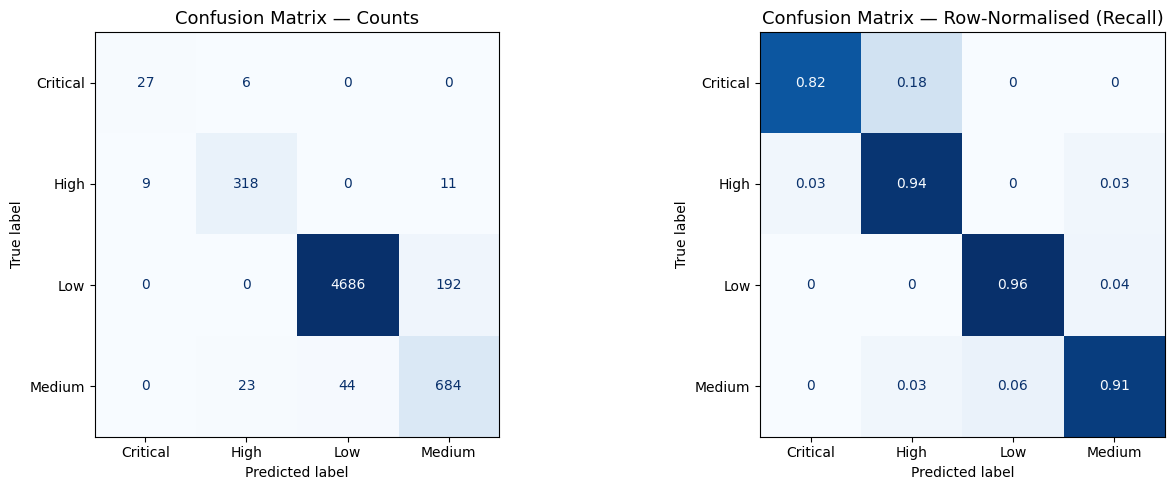

Saved: confusion_matrix_xgboost.png


In [22]:
"""
## 14. Confusion Matrix
"""
 
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
 
print("Confusion Matrix (counts):")
print(cm_df)
print()
 
# Normalised (row = recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm_df = pd.DataFrame(cm_norm.round(3), index=le.classes_, columns=le.classes_)
print("Confusion Matrix (row-normalised / recall):")
print(cm_norm_df)
 
# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Raw counts
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Confusion Matrix — Counts", fontsize=13)
 
# Normalised
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=le.classes_).plot(
    ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_title("Confusion Matrix — Row-Normalised (Recall)", fontsize=13)
 
plt.tight_layout()
plt.savefig("confusion_matrix_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_xgboost.png")
 

Top 20 features by gain importance:
                   feature  importance
             backlog_count    0.261377
            classes_missed    0.089430
     mentor_meetings_count    0.067449
              stress_score    0.055637
     attendance_percentage    0.046071
                      cgpa    0.028611
     time_management_score    0.023987
        internal_marks_avg    0.018748
assignment_submission_rate    0.018409
       certification_count    0.016868
    financial_stress_score    0.014433
    course_completion_rate    0.014197
         quiz_attempt_rate    0.013839
    video_watch_percentage    0.010658
       counseling_sessions    0.010581
          attendance_trend    0.010365
            aptitude_score    0.010085
        presentation_score    0.009783
      study_hours_per_week    0.009166
    group_discussion_score    0.008686


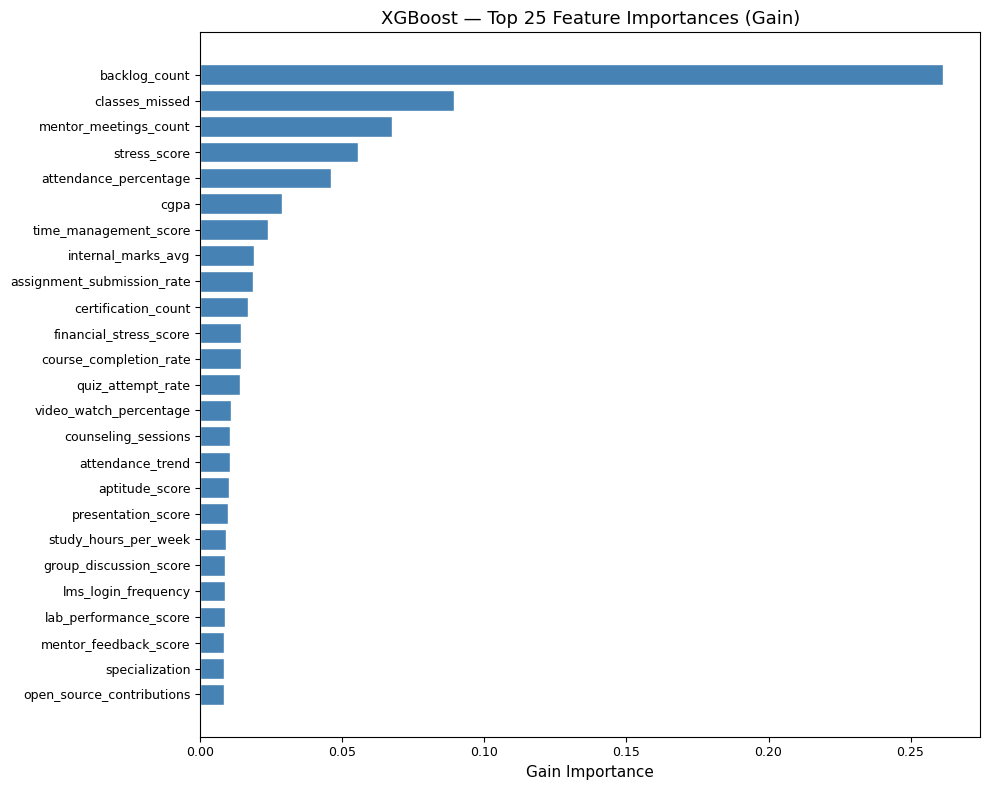

Saved: feature_importance_xgboost.png
Saved: feature_importance_xgboost.csv


In [23]:
"""
## 15. Feature Importance
 
XGBoost's built-in `feature_importances_` (gain-based) is extracted after
the pipeline preprocessor has transformed the data.
 
The feature names after OrdinalEncoder match the original column names directly,
so we can map them back unambiguously.
"""
 
# Reconstruct feature names after ColumnTransformer
feature_names = numeric_cols + categorical_cols   # order matches ColumnTransformer
 
importances = xgb_pipeline.named_steps["classifier"].feature_importances_
 
fi_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
 
print("Top 20 features by gain importance:")
print(fi_df.head(20).to_string(index=False))
 
# ── Plot ──
TOP_N = 25
 
fig, ax = plt.subplots(figsize=(10, 8))
top = fi_df.head(TOP_N)
ax.barh(top["feature"][::-1], top["importance"][::-1], color="steelblue", edgecolor="white")
ax.set_xlabel("Gain Importance", fontsize=11)
ax.set_title(f"XGBoost — Top {TOP_N} Feature Importances (Gain)", fontsize=13)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig("feature_importance_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importance_xgboost.png")
 
fi_df.to_csv("feature_importance_xgboost.csv", index=False)
print("Saved: feature_importance_xgboost.csv")
 

In [24]:
"""
## 16. Stratified 5-Fold Cross-Validation
 
Run on the full labelled dataset (X, y_enc) to confirm the test-set metrics
are not a lucky split artefact.  Metric: weighted F1.
 
Note: this retrains 5× without early stopping; treat as a directional check,
not the primary evaluation.
"""
 
cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                objective="multi:softprob",
                eval_metric="mlogloss",
                num_class=len(le.classes_),
                # n_estimators=xgb_clf.best_iteration + 1,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=5,
                gamma=1,
                reg_alpha=0.1,
                reg_lambda=1,
                random_state=42,
                n_jobs=-1,
                verbosity=0,
            ),
        ),
    ]
)
 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
cv_scores = cross_val_score(
    cv_pipeline, X, y_enc,
    cv=skf,
    scoring="f1_weighted",
    n_jobs=-1,
)
 
print("5-Fold CV Weighted F1 scores:", cv_scores.round(4))
print(f"Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")
 

5-Fold CV Weighted F1 scores: [0.9607 0.9579 0.961  0.961  0.9623]
Mean: 0.9606  |  Std: 0.0015


                         Model  Accuracy  Weighted F1  Macro F1  Critical Recall  High Recall
Logistic Regression (baseline)    0.9402       0.9439    0.8139           0.8182       0.8817
                  XGBoost (v2)    0.9525       0.9542    0.8804           0.8182       0.9408

Saved: model_comparison.csv


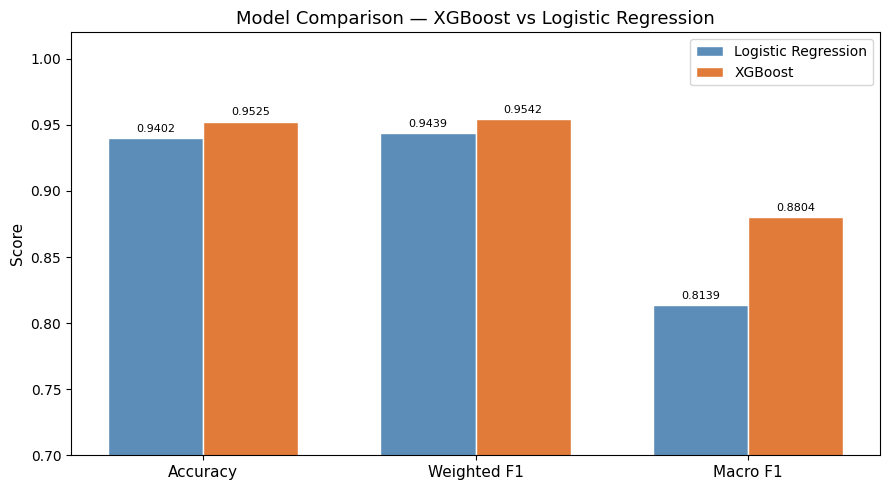

Saved: model_comparison_chart.png


In [25]:
"""
## 17. Model Comparison — XGBoost vs Logistic Regression Baseline
 
The Logistic Regression baseline (model_v1_baseline) achieved:
  - Accuracy : 95 %
  - Macro F1  : ~0.83
 
This section reruns LR on the same train/test split for a fair apples-to-apples
comparison and prints a summary table.
"""
 
from sklearn.preprocessing import OneHotEncoder as OHE
 
# LR needs a different preprocessor (OHE instead of OrdinalEncoder)
lr_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OHE(handle_unknown="ignore", sparse_output=False)),
            ]),
            categorical_cols,
        ),
    ],
    remainder="drop",
)
 
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)
 
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
 
# Metric comparison
results = {
    "Model": ["Logistic Regression (baseline)", "XGBoost (v2)"],
    "Accuracy": [
        round(accuracy_score(y_test, lr_pred), 4),
        round(acc, 4),
    ],
    "Weighted F1": [
        round(f1_score(y_test, lr_pred, average="weighted"), 4),
        round(f1_weighted, 4),
    ],
    "Macro F1": [
        round(f1_score(y_test, lr_pred, average="macro"), 4),
        round(f1_macro, 4),
    ],
    "Critical Recall": [
        round(classification_report(y_test, lr_pred, output_dict=True)[str(le.transform(["Critical"])[0])]["recall"], 4),
        round(classification_report(y_test, y_pred,  output_dict=True)[str(le.transform(["Critical"])[0])]["recall"], 4),
    ],
    "High Recall": [
        round(classification_report(y_test, lr_pred, output_dict=True)[str(le.transform(["High"])[0])]["recall"], 4),
        round(classification_report(y_test, y_pred,  output_dict=True)[str(le.transform(["High"])[0])]["recall"], 4),
    ],
}
 
comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))
comparison_df.to_csv("model_comparison.csv", index=False)
print("\nSaved: model_comparison.csv")
 
# ── Bar chart ──
metrics = ["Accuracy", "Weighted F1", "Macro F1"]
x = np.arange(len(metrics))
width = 0.35
 
fig, ax = plt.subplots(figsize=(9, 5))
bars_lr  = ax.bar(x - width/2, comparison_df.loc[0, metrics], width, label="Logistic Regression", color="#5B8DB8", edgecolor="white")
bars_xgb = ax.bar(x + width/2, comparison_df.loc[1, metrics], width, label="XGBoost",             color="#E07B3A", edgecolor="white")
 
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model Comparison — XGBoost vs Logistic Regression", fontsize=13)
ax.set_ylim(0.7, 1.02)
ax.legend(fontsize=10)
ax.bar_label(bars_lr,  fmt="%.4f", padding=3, fontsize=8)
ax.bar_label(bars_xgb, fmt="%.4f", padding=3, fontsize=8)
plt.tight_layout()
plt.savefig("model_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison_chart.png")
 
 

In [26]:
"""
## 18. Save Final Model
 
The full sklearn Pipeline (preprocessor + XGBClassifier) is saved with joblib.
This is the artefact consumed by the FastAPI service in Week 3.
 
Files produced:
  xgboost_academic_risk_pipeline.pkl   — the full pipeline
  label_encoder_academic_risk.pkl      — LabelEncoder (already saved in Cell 5)
"""
 
MODEL_PATH   = "xgboost_academic_risk_pipeline.pkl"
ENCODER_PATH = "label_encoder_academic_risk.pkl"
 
joblib.dump(xgb_pipeline, MODEL_PATH)
joblib.dump(le,           ENCODER_PATH)
 
print(f"Model saved   : {MODEL_PATH}")
print(f"Encoder saved : {ENCODER_PATH}")
 
# Quick reload smoke-test
loaded_pipeline = joblib.load(MODEL_PATH)
loaded_le       = joblib.load(ENCODER_PATH)
 
smoke_pred = loaded_pipeline.predict(X_test[:5])
print("\nSmoke-test predictions (encoded):", smoke_pred)
print("Decoded                          :", loaded_le.inverse_transform(smoke_pred))
print("Smoke test PASSED.")
 

Model saved   : xgboost_academic_risk_pipeline.pkl
Encoder saved : label_encoder_academic_risk.pkl

Smoke-test predictions (encoded): [2 2 2 2 2]
Decoded                          : ['Low' 'Low' 'Low' 'Low' 'Low']
Smoke test PASSED.


In [27]:

"""
## 19. Inference Helper Function
 
Drop this function into the FastAPI service when building `/predict`.
It accepts a dict of raw feature values (as the model expects them),
runs the full pipeline, and returns the risk band label and per-class
probabilities in the shared data-contract format.
"""
 
def predict_student_risk(feature_dict: dict) -> dict:
    """
    Parameters
    ----------
    feature_dict : dict
        Keys = column names matching X.columns (62 features, no leakage cols).
        Values = raw values exactly as they appear in the dataset.
 
    Returns
    -------
    dict  matching the shared risk-profile contract:
        {
          "student_id": ...,       # caller must inject this
          "risk_band": str,        # "Low" / "Medium" / "High" / "Critical"
          "risk_score": float,     # probability of predicted class × 100
          "class_probabilities": { "Low": .., "Medium": .., "High": .., "Critical": .. },
          "last_updated": str      # caller must inject ISO timestamp
        }
    """
    import datetime
 
    pipeline = joblib.load("xgboost_academic_risk_pipeline.pkl")
    enc      = joblib.load("label_encoder_academic_risk.pkl")
 
    row = pd.DataFrame([feature_dict])
    pred_enc   = pipeline.predict(row)[0]
    pred_proba = pipeline.predict_proba(row)[0]
 
    risk_band  = enc.inverse_transform([pred_enc])[0]
    risk_score = round(float(pred_proba[pred_enc]) * 100, 2)
 
    class_probs = {
        cls: round(float(prob), 4)
        for cls, prob in zip(enc.classes_, pred_proba)
    }
 
    return {
        "student_id"         : feature_dict.get("student_id", "UNKNOWN"),
        "risk_band"          : risk_band,
        "risk_score"         : risk_score,
        "class_probabilities": class_probs,
        "last_updated"       : datetime.datetime.utcnow().isoformat() + "Z",
    }
 
 
# Example call (comment out if running headless)
# sample_row = X_test.iloc[0].to_dict()
# result = predict_student_risk(sample_row)
# print(result)
 

In [28]:

"""
## 20. Write metrics.md
 
Person A's Definition of Done requires a `metrics.md` with real precision /
recall numbers.  This cell writes it automatically from the evaluation above.
"""
 
report_dict = classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    output_dict=True,
)
 
md_lines = [
    "# Model Metrics — Academic Risk Band Prediction",
    "",
    "**Model**: XGBoost (v2, production)  ",
    f"**Test set size**: {len(y_test)} rows (20 % stratified hold-out)  ",
    "",
    "## Overall",
    "",
    f"| Metric | Score |",
    "| --- | --- |",
    f"| Accuracy | {acc:.4f} |",
    f"| Weighted F1 | {f1_weighted:.4f} |",
    f"| Macro F1 | {f1_macro:.4f} |",
    "",
    "## Per-Class",
    "",
    "| Class | Precision | Recall | F1 | Support |",
    "| --- | --- | --- | --- | --- |",
]
 
for cls in le.classes_:
    r = report_dict[cls]
    md_lines.append(
        f"| {cls} | {r['precision']:.4f} | {r['recall']:.4f} | {r['f1-score']:.4f} | {int(r['support'])} |"
    )
 
md_lines += [
    "",
    "## Why Recall Matters More Than Accuracy",
    "",
    "The dataset is heavily skewed (Low ≈ 81 %).  A naïve model that predicts",
    "*Low* for every student would achieve ~81 % accuracy while missing every",
    "High/Critical student.  We therefore optimise for **recall on High and Critical**",
    "classes — missing an at-risk student is far costlier than a false alarm.",
    "",
    "## Model Comparison vs Logistic Regression Baseline",
    "",
    "| Model | Accuracy | Weighted F1 | Macro F1 |",
    "| --- | --- | --- | --- |",
    f"| Logistic Regression | {accuracy_score(y_test, lr_pred):.4f} | {f1_score(y_test, lr_pred, average='weighted'):.4f} | {f1_score(y_test, lr_pred, average='macro'):.4f} |",
    f"| XGBoost (v2)        | {acc:.4f} | {f1_weighted:.4f} | {f1_macro:.4f} |",
    "",
    "## Why XGBoost + Balanced Weights",
    "",
    "- XGBoost handles the mix of numeric and ordinal-encoded categorical features",
    "  without requiring feature scaling, which Logistic Regression needs.",
    "- Gain-based feature importance is available natively and feeds the SHAP",
    "  explainability layer (Week 3).",
    "- `compute_sample_weight('balanced')` up-weights the minority Critical / High",
    "  classes during training, raising their recall without discarding data.",
    "- Early stopping on a validation hold-out prevents overfitting to the dominant",
    "  Low class.",
]
 
with open("metrics.md", "w", encoding="utf-8") as f:
    f.write("\n".join(md_lines))
 
print("Saved: metrics.md")


Saved: metrics.md


In [29]:

"""
## 21. Artefacts Produced
 
| File | Description |
| --- | --- |
| `xgboost_academic_risk_pipeline.pkl` | Full sklearn Pipeline (preprocessor + XGBClassifier) |
| `label_encoder_academic_risk.pkl`    | LabelEncoder mapping 0–3 → class names |
| `confusion_matrix_xgboost.png`       | Counts + row-normalised confusion matrices |
| `feature_importance_xgboost.png`     | Top-25 feature importance bar chart |
| `feature_importance_xgboost.csv`     | Full feature importance table |
| `model_comparison.csv`               | XGBoost vs LR metric comparison |
| `model_comparison_chart.png`         | Bar chart of model comparison |
| `metrics.md`                         | Definition-of-Done metrics file |
 
Next steps (Week 3):
- Wrap pipeline in FastAPI POST /predict (Person A)
- Add SHAP top-3 factors per student (Person A)
- Person B calls /predict to feed branching logic
- Person C calls /predict to populate the dashboard
"""
 
print("=== model_v2_xgboost_final.py complete ===")
print("All artefacts listed above should now exist in the working directory.")

=== model_v2_xgboost_final.py complete ===
All artefacts listed above should now exist in the working directory.
